# EDA: License Plate Detection

In [3]:
import os
import glob
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
def parse_annotation(xml_file):
    """
    Parse an XML annotation file and extract bounding box information.
    """
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find('filename').text
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    bboxes = []
    for obj in root.findall('object'):
        label = obj.find('name').text
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)
        bbox_width = xmax - xmin
        bbox_height = ymax - ymin
        bboxes.append([label, xmin, ymin, xmax, ymax, bbox_width, bbox_height])

    return filename, width, height, bboxes


In [ ]:
annotations_dir = "data/images/"
xml_files = glob.glob(os.path.join(annotations_dir, "*.xml"))

data = []
for xml_file in xml_files:
    filename, img_width, img_height, bboxes = parse_annotation(xml_file)
    for bbox in bboxes:
        label, xmin, ymin, xmax, ymax, bbox_width, bbox_height = bbox
        data.append([filename, img_width, img_height, xmin, ymin, xmax, ymax, bbox_width, bbox_height])

df = pd.DataFrame(data, columns=["filename", "img_width", "img_height", "xmin", "ymin", "xmax", "ymax", "bbox_width", "bbox_height"])

# Display the first few rows
print(df.head())


    filename  img_width  img_height         label  xmin  ymin  xmax  ymax  \
0  N107.jpeg        441         363  number_plate   207   174   356   287   
1  N113.jpeg        400         300  number_plate    39   129   108   157   
2   N62.jpeg        500         269  number_plate   289   188   421   232   
3   N89.jpeg        500         393  number_plate   150   217   378   269   
4   N88.jpeg        610         338  number_plate   208    89   370   173   

   bbox_width  bbox_height  
0         149          113  
1          69           28  
2         132           44  
3         228           52  
4         162           84  


### Image Size Distribution

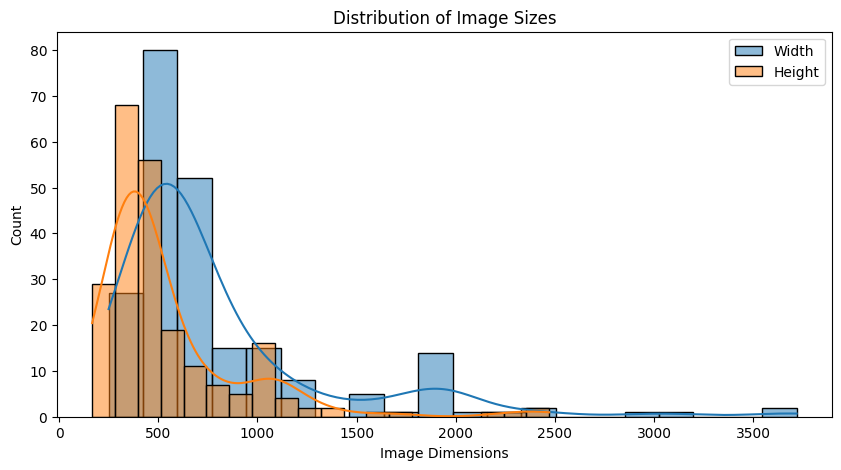

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df["img_width"], bins=20, kde=True, label="Width")
sns.histplot(df["img_height"], bins=20, kde=True, label="Height")
plt.xlabel("Image Dimensions")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of Image Sizes")
plt.show()


### Bounding Box Size Distribution

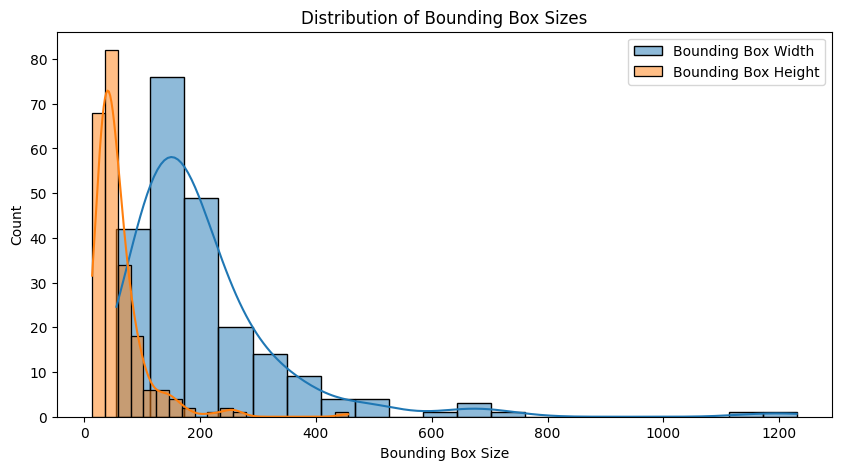

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df["bbox_width"], bins=20, kde=True, label="Bounding Box Width")
sns.histplot(df["bbox_height"], bins=20, kde=True, label="Bounding Box Height")
plt.xlabel("Bounding Box Size")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of Bounding Box Sizes")
plt.show()


### Bouding Box Positioning

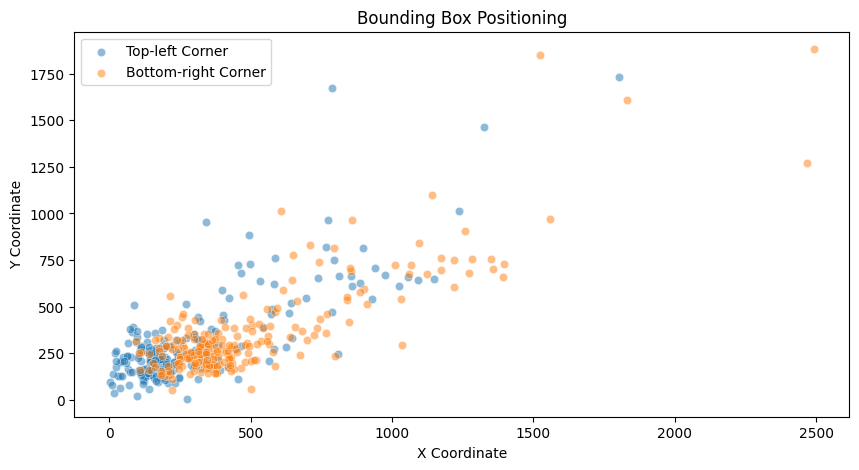

In [11]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="xmin", y="ymin", alpha=0.5, label="Top-left Corner")
sns.scatterplot(data=df, x="xmax", y="ymax", alpha=0.5, label="Bottom-right Corner")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.title("Bounding Box Positioning")
plt.show()
